In [21]:
from core.sr_study_analysis import run_analysis, run_selected_configs, ExperimentSpec
from core.sr_sim import StudyType

In [22]:
from core.models import AvarModel, REGISTRY

class ChristieModel(AvarModel):
    """IID Normal returns."""
    name        = "IID Normal"
    short_name  = "iid_normal_christie"
    param_names = ()

    def _avar(self, sr, T, **kw):
        return 1.0 + sr**2 / 2.0
        #return 1.0 + sr**2 / 2.0 + (7/8*sr**2 - 1)/T

    def fit(self, x):
        return {}
    
    def _correct_bias(self, T, sr_hat, **kw):
        return sr_hat/(1 + 0.5/T)
    

class MyModel(AvarModel):
    """IID Normal returns."""
    name        = "IID Normal"
    short_name  = "iid_normal_my"
    param_names = ()

    def _avar(self, sr, T, **kw):
        return 1.0 + sr**2 / 2.0
        #return 1.0 + sr**2 / 2.0 + (7/8*sr**2 - 1)/T

    def fit(self, x):
        return {}
    
    def _correct_bias(self, T, sr_hat, **kw):
        return sr_hat/(1 + 0.75/T)
    
import numpy as np
from scipy.special import gammaln
class ExactAdjModel(AvarModel):
    """IID Normal returns."""
    name        = "IID Normal"
    short_name  = "exact_adj"
    param_names = ()

    def _avar(self, sr, T, **kw):
        return 1.0 + sr**2 / 2.0
        #return 1.0 + sr**2 / 2.0 + (7/8*sr**2 - 1)/T

    def fit(self, x):
        return {}
    
    def _correct_bias(self, T, sr_hat, **kw):
        n = T - 1
        return sr_hat /np.exp(0.5*np.log(n/2) + gammaln((n-1)/2) - gammaln(n/2))
    
class NoAdjModel(AvarModel):
    """IID Normal returns."""
    name        = "IID Normal"
    short_name  = "no_adj"
    param_names = ()

    def _avar(self, sr, **kw):
        return 1.0 + sr**2 / 2.0

    def fit(self, x):
        return {}
    
    def _correct_bias(self, T, sr_hat, **kw):
        return sr_hat
    

        
REGISTRY["christie"] = ChristieModel()
REGISTRY["iid_normal_my"] = MyModel()
#REGISTRY["exact_adj"] = ExactAdjModel()
REGISTRY["no_adj"] = NoAdjModel()


In [28]:
# name : (dgp_names, model_short_names)
scenarios = {
    "christie": (
        ["iid_normal"],
        ["iid_normal_my", "christie", "no_adj"],#, "exact_adj"
    ),
}

In [29]:
N_SIM  = 50_000
N_JOBS = 8

experiments = {
    "christie": ExperimentSpec(
        scenario   = scenarios["christie"],
        param_name = "T",
        param_values = [15, 20, 30, 50],
        study_type = StudyType.TWO_SIDED_COVERAGE,
        calib_sigma   = 2.0,
        sr_default = 0.25,
        th_moments = False,
        bias_adj = True,
        n_default  = N_SIM,
        n_jobs = N_JOBS,
    ),
}

In [30]:
# ── coverage / size runs ──────────────────────────────────────────────────────
run_selected_configs(
    experiments,
    selected_experiments=[
        "christie",
    ],
)


  Experiment: christie
  [1/4]  T=15  (TWO_SIDED_COVERAGE)
  [2/4]  T=20  (TWO_SIDED_COVERAGE)
  [3/4]  T=30  (TWO_SIDED_COVERAGE)
  [4/4]  T=50  (TWO_SIDED_COVERAGE)


In [31]:
#common
line_plot_kargs = dict(reverse=False, 
                       linewidth=1,)

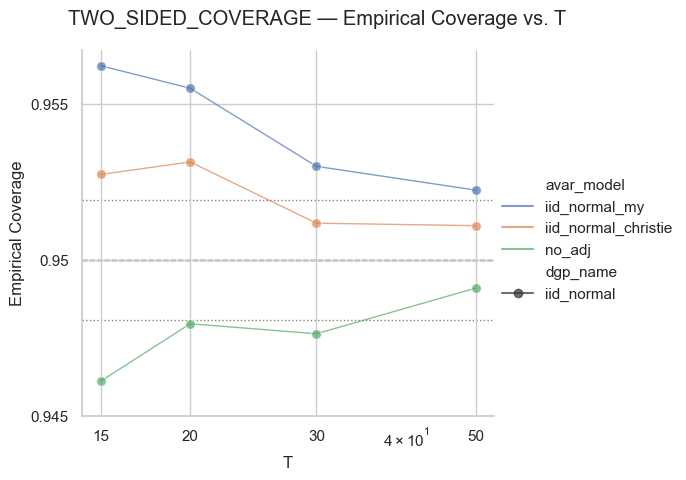

In [33]:
run_analysis(experiments, "christie", alpha=0.05, plot_mask=[0,0,1],
             line_plot_kargs=line_plot_kargs |
             dict(log=True, yticks=[0.945, 0.95, 0.955], xticks= [15, 20, 30, 50]))

In [ ]:
from core.dgp import IIDProcess, NormalInnov
models = [ChristieModel(), MyModel(), NoAdjModel()]
dgp = IIDProcess(NormalInnov(0.5, 2.0))
rng = np.random.default_rng(42)
T=30

for _ in range(30_000):
    dgp.simulate(T, rng)
    for model in models:
        sr_hat = X.mean(axis=1) / X.std(axis=1, ddof=1)

In [ ]:
"""
Experimento: Christie (1+1/2T) vs Bao (1+3/4T) vs Corrección Exacta
"""
import numpy as np
from scipy.special import gammaln
import matplotlib.pyplot as plt

MU, SIGMA = 0.5, 2.0
SR_TRUE   = MU / SIGMA
T_GRID    = [20, 30, 50, 100, 200, 500]
N_SIM     = 200_000
RNG       = np.random.default_rng(42)

def factor_exact(T):
    n = T - 1
    return np.exp(0.5*np.log(n/2) + gammaln((n-1)/2) - gammaln(n/2))

def factor_christie(T): return 1 + 1/(2*T)
def factor_bao(T):      return 1 + 3/(4*T)

T_arr         = np.array(T_GRID)
exact_vals    = np.array([factor_exact(T)    for T in T_GRID])
christie_vals = np.array([factor_christie(T) for T in T_GRID])
bao_vals      = np.array([factor_bao(T)      for T in T_GRID])
delta_chr     = np.abs(exact_vals - christie_vals)
delta_bao     = np.abs(exact_vals - bao_vals)

res_chr, res_bao = [], []
for T in T_GRID:
    X      = RNG.normal(MU, SIGMA, size=(N_SIM, T))
    sr_hat = X.mean(axis=1) / X.std(axis=1, ddof=1)
    res_chr.append(sr_hat.mean() / factor_christie(T) - SR_TRUE)
    res_bao.append(sr_hat.mean() / factor_bao(T)      - SR_TRUE)

res_chr = np.array(res_chr)
res_bao = np.array(res_bao)

print(f"\n{'T':>6} | {'exacto':>8} | {'Christie':>9} | {'Bao':>8} | {'δ_Chr':>8} | {'δ_Bao':>8} | {'res×T Chr':>10} | {'res×T Bao':>10} | {'res×T² Bao':>11}")
print("-"*100)
for i, T in enumerate(T_GRID):
    print(f"{T:>6} | {exact_vals[i]:>8.5f} | {christie_vals[i]:>9.5f} | {bao_vals[i]:>8.5f} | "
          f"{delta_chr[i]:>8.6f} | {delta_bao[i]:>8.6f} | "
          f"{res_chr[i]*T:>10.4f} | {res_bao[i]*T:>10.4f} | {res_bao[i]*T**2:>11.3f}")


[]

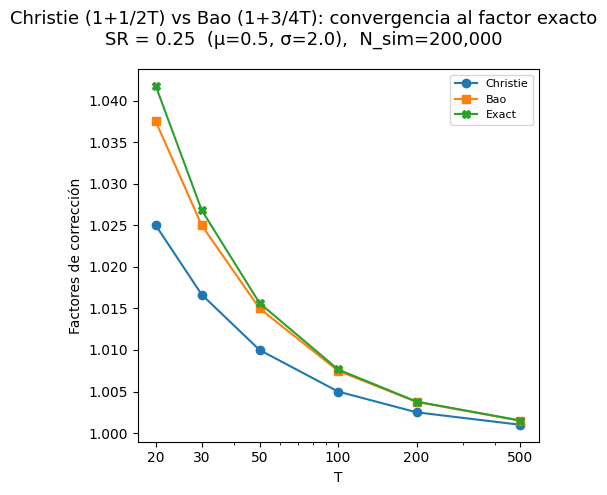

In [20]:
fig, axes = plt.subplots(1, 1, figsize=(5, 5))
fig.suptitle(
    f"Christie (1+1/2T) vs Bao (1+3/4T): convergencia al factor exacto\n"
    f"SR = {SR_TRUE:.2f}  (μ={MU}, σ={SIGMA}),  N_sim={N_SIM:,}",
    fontsize=13)

ax = axes
ax.plot(T_GRID, christie_vals, "o-", color="tab:blue",   label="Christie")
ax.plot(T_GRID, bao_vals, "s-", color="tab:orange", label="Bao")
ax.plot(T_GRID, exact_vals, "X-", color="tab:green", label="Exact")
ax.set_xlabel("T"); 
ax.set_ylabel("Factores de corrección")
ax.legend(fontsize=8); 
ax.set_xscale("log"); 
ax.set_xticks([20, 30, 50, 100, 200, 500])
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.get_xaxis().set_minor_formatter(plt.NullFormatter())
#ax.grid(True, which="both", ls="--", alpha=0.4)


plt.tight_layout()
plt.plot()

In [ ]:
from core.bias_correction_comp import run_bias_comp

In [ ]:
class ChristieModel(AvarModel):
    """IID Normal returns."""
    name        = "IID Normal"
    short_name  = "christie"
    param_names = ()

    def _avar(self, sr, T, **kw):
        return 1.0 + sr**2 / 2.0

    def fit(self, x):
        return {}
    
    def _correct_bias(self, T, sr_hat, **kw):
        return sr_hat/(1 + 0.5/T)
    
import numpy as np
from scipy.special import gammaln
class ExactAdjModel(AvarModel):
    """IID Normal returns."""
    name        = "IID Normal"
    short_name  = "exact"
    param_names = ()

    def _avar(self, sr, T, **kw):
        return 1.0 + sr**2 / 2.0
        #return 1.0 + sr**2 / 2.0 + (7/8*sr**2 - 1)/T

    def fit(self, x):
        return {}
    
    def _correct_bias(self, T, sr_hat, **kw):
        n = T - 1
        return sr_hat /np.exp(0.5*np.log(n/2) + gammaln((n-1)/2) - gammaln(n/2))
    
class CorrectModel(AvarModel):
    """IID Normal returns."""
    name        = "IID Normal"
    short_name  = "correct"
    param_names = ()

    def _avar(self, sr, **kw):
        return 1.0 + sr**2 / 2.0

    def fit(self, x):
        return {}
    
    def _correct_bias(self, T, sr_hat, **kw):
        return sr_hat/(1 + 0.75/T)

In [ ]:
N    = 500_000
Ts   = [15, 30, 50, 100, 300]
dgp  = IIDProcess(NormalInnov()).calibrate_params(mu=0.5, sigma=1)
models = [ExactAdjModel(), CorrectModel(), ChristieModel()]

In [ ]:
run_bias_comp(0.5, N, Ts, dgp, models)